In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [125]:
df = pd.read_csv("loan_approval_data.csv")
df.sample(20)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
407,408.0,9587.0,3224.0,Contract,21.0,Married,0.0,605.0,3.0,0.45,19924.0,24882.0,15063.0,60.0,NaN,Urban,Not Graduate,Female,Government,No
813,814.0,3970.0,6764.0,Salaried,45.0,Married,0.0,788.0,3.0,0.59,3937.0,29348.0,2620.0,84.0,Business,Rural,Graduate,Female,Private,No
351,352.0,10130.0,9098.0,Salaried,45.0,Single,3.0,651.0,0.0,NaN,329.0,35367.0,20739.0,24.0,Home,Semiurban,Graduate,Male,Business,Yes
391,392.0,7726.0,5776.0,Salaried,30.0,Married,2.0,726.0,2.0,0.33,3951.0,14713.0,5179.0,36.0,Education,Urban,Graduate,Female,NaN,Yes
835,836.0,9863.0,8533.0,Salaried,32.0,Married,2.0,603.0,NaN,0.53,9436.0,48692.0,36191.0,24.0,Car,Semiurban,Graduate,Male,MNC,No
604,605.0,10017.0,4293.0,Contract,NaN,Married,3.0,684.0,2.0,0.22,9554.0,21282.0,37355.0,12.0,Business,Urban,Graduate,Male,Business,Yes
403,404.0,NaN,4473.0,Salaried,27.0,Married,1.0,570.0,3.0,0.17,7041.0,42432.0,16739.0,60.0,Home,Semiurban,Not Graduate,Female,Private,No
624,625.0,8254.0,9110.0,Salaried,52.0,Married,1.0,566.0,1.0,0.23,6572.0,NaN,26957.0,12.0,Car,Semiurban,Graduate,Female,Private,No
347,348.0,15500.0,5043.0,Salaried,27.0,Single,1.0,746.0,1.0,0.24,12773.0,43663.0,14027.0,48.0,Business,Urban,Graduate,Male,Business,Yes
28,29.0,5556.0,1622.0,Salaried,37.0,Married,NaN,572.0,2.0,0.23,4608.0,25378.0,11985.0,60.0,Business,Urban,Not Graduate,Male,Unemployed,No


# Handle Missing values

In [126]:
# Differentiate categorical values and numerical values

categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [127]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [128]:
col_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = col_imp.fit_transform(df[categorical_cols])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'Is Loan approved or not?')

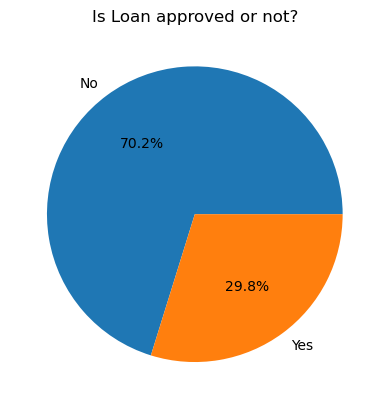

In [129]:
# how balanced our classes are?

class_count = df["Loan_Approved"].value_counts()
plt.pie(class_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

2

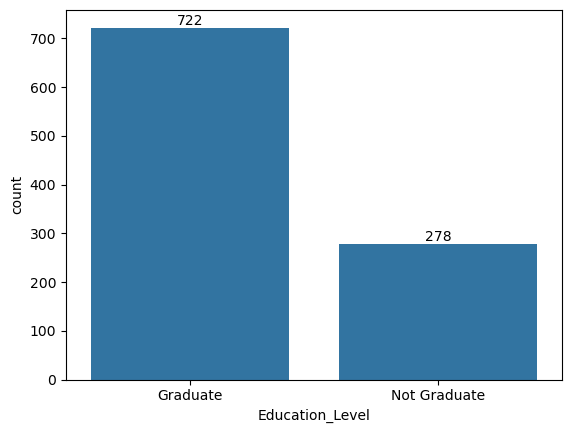

In [130]:
# Analyze categories

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])
df["Education_Level"].nunique()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

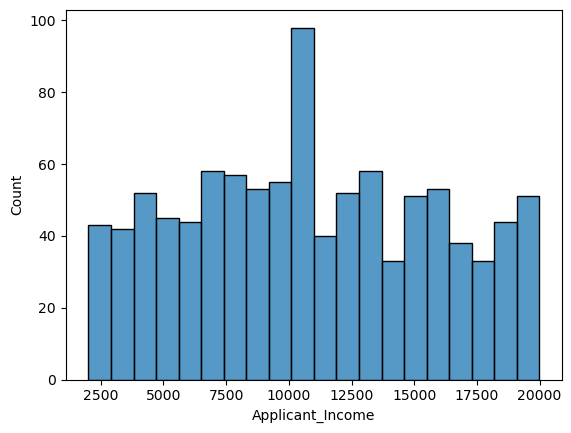

In [99]:
# Analyze income

sns.histplot(
    data= df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

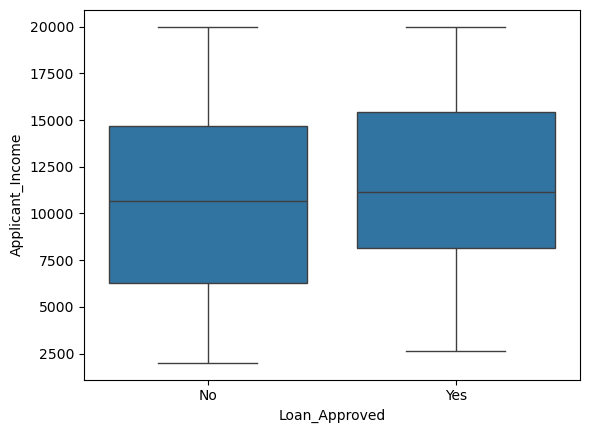

In [100]:
# outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

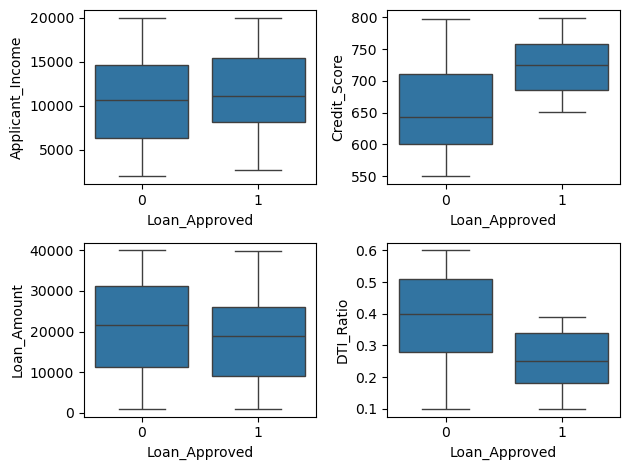

In [106]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="Loan_Amount")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="DTI_Ratio")

plt.tight_layout()

# Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label encoding

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df.head()

# One hot encoding

cols = ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns = cols), encoded_df], axis=1)

In [ ]:
df.info()

# Correlation Heatmap

<Axes: >

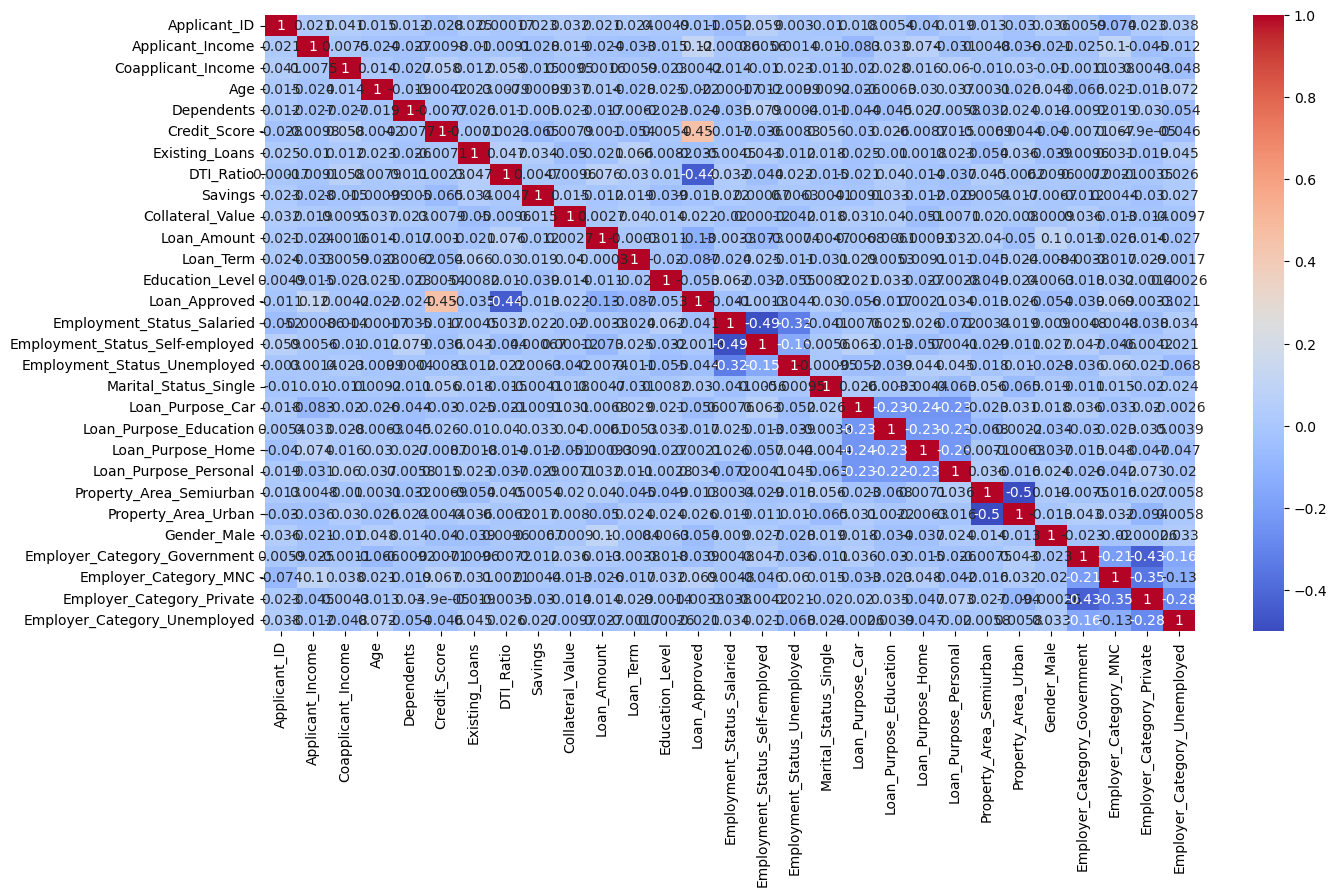

In [143]:
# Load all numerical values to figure out the correlation between each variable

num_col = df.select_dtypes(include = ["number"])
corr_matrix = num_col.corr()

plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,
            fmt='.2g',
            annot=True,
            cmap="coolwarm")
    

# Test-Train-Split and Feature scaling

In [152]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [153]:
X.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

In [157]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [159]:
X_test_scaler

array([[ 0.07859054,  0.42610546,  0.55091079, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.84335174,  1.00971366,  0.58995935, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.85397342, -0.67557096, -0.54558674, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-1.02960507, -0.67980585, -0.10106072, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.40432216, -0.37650705, -0.97825874, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-1.48987801, -0.73647272, -1.24497436, ..., -0.41388776,
         1.16316   , -0.30723158]])

# Train and evaluate the model

In [174]:
# Logistic regression

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaler, y_train) 

y_pred = logistic_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))

Precision:  0.7868852459016393
Accuracy:  0.87
Recall:  0.7868852459016393
f1 Score:  0.7868852459016393
Confusion MX:  [[126  13]
 [ 13  48]]


In [177]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaler, y_train) 

y_pred = knn_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))



Precision:  0.5957446808510638
Accuracy:  0.74
Recall:  0.45901639344262296
f1 Score:  0.5185185185185185
Confusion MX:  [[120  19]
 [ 33  28]]


In [179]:
# Naive bayes

from sklearn.naive_bayes import GaussianNB
gb_model = GaussianNB()
gb_model.fit(X_train_scaler, y_train) 

y_pred = gb_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))

Precision:  0.8035714285714286
Accuracy:  0.865
Recall:  0.7377049180327869
f1 Score:  0.7692307692307693
Confusion MX:  [[128  11]
 [ 16  45]]


# Best Model on the basis of Precision => Naive Bayes

# Feature engineering to improve model

In [183]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2   #Since DTi and credit score or more impactful features of data as per heatmap. Increase their impact by **2
df["Credit_Score_sq"] = df["Credit_Score"] **2


X = df.drop(columns = ["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [184]:
# Logistic regression

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaler, y_train) 

y_pred = logistic_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))

Precision:  0.7868852459016393
Accuracy:  0.87
Recall:  0.7868852459016393
f1 Score:  0.7868852459016393
Confusion MX:  [[126  13]
 [ 13  48]]


In [185]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaler, y_train) 

y_pred = knn_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))

Precision:  0.5957446808510638
Accuracy:  0.74
Recall:  0.45901639344262296
f1 Score:  0.5185185185185185
Confusion MX:  [[120  19]
 [ 33  28]]


In [186]:
# Naive bayes

from sklearn.naive_bayes import GaussianNB
gb_model = GaussianNB()
gb_model.fit(X_train_scaler, y_train) 

y_pred = gb_model.predict(X_test_scaler)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1 Score: ", f1_score(y_test, y_pred))
print("Confusion MX: ", confusion_matrix(y_test, y_pred))

Precision:  0.8035714285714286
Accuracy:  0.865
Recall:  0.7377049180327869
f1 Score:  0.7692307692307693
Confusion MX:  [[128  11]
 [ 16  45]]
